# Transition Matrix Elements

Here, we compute transition elements of the form $(\psi_{\text{resonance},\theta}|r_\theta|\psi_{\text{bound}, \theta})$, plot these elements for multiple $\theta$, and compare these results to the EC-backrotated result at $\theta=0$.

Note for future: $2\theta\ge \arg(E)$. Further, $V(r) = -\alpha \exp(-br^2)\rightarrow -\alpha\exp(-br^2e^{2i\theta}) = -\alpha\exp(-br^2cos(2\theta)-bir^2\sin(2\theta)) = -\alpha \exp(-br^2\cos(2\theta))\exp(-ibr^2\sin(2\theta))$ which real
part only decays up until $\theta=\pi/4$. All Gaussian potential have a max $\phi$ of $\pi/4$ because past that point, the potential is no longer convergent and ABC doesn't apply.

Everything in this notebook uses System 2 (see systems.ipynb)

In [1]:
from src.ecensemble import ECEnsemble
from src.ec import ECSystem, TakagiRegularization
from src.dvr import DVR
from src.tikhonov import Tikhonov
from src.utils import decompose_stats, plot_stats, get_plots_path

import numpy as np
from numpy import pi, exp
import random
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

import logging
logging.basicConfig(level=logging.WARNING, format="[%(levelname)s] %(name)s: %(message)s")
logging.getLogger("matplotlib").setLevel(logging.WARNING)

In [2]:
save_plots = True
plots_folder = get_plots_path() / "ec_backrotated_transitions_wstats"
plots_folder.mkdir(exist_ok=True, parents=True)

### Define exact values and setup DVR for bound state and resonance

In [3]:
# define system parameters and exact data

# all three values below confirmed with Zeldovich regularization and supported by complex-scaling
real_bound = -2.54340163214942386809685268328 + 1j*0.0
real_res = 0.258226322613254148836675851021 - 1j*0.164325859989219650841596781234 
real_telem = 0.96290976501184810465 - 1j*0.32153245892806156942

# system parameters
n = 256
L = 50.0
phi_stable = pi/6 # phi in the good region
def gauss_p(r):
    return -10 * exp(-r**2)

# DVR systems for bound state and resonance
sbound_system = DVR(n, L, rotation_angle=0.0, potential=gauss_p, l=0)
pres_system = DVR(n, L, rotation_angle=phi_stable, potential=gauss_p, l=1)

# reference bound / resonant state (so we don't have to repeatedly compute it)
reference_bound_state = sbound_system.closest_to_resonance(real_bound)[1][:, 0]
reference_res_state = pres_system.closest_to_resonance(real_res)[1][:, 0]

In [4]:
# define function to quickly check bound / resonance energy, transition matrix element, and residuals using EC
def quick_predict(phi_predict, ec_system):
    # get bound state (no need to use EC here). This shouldn't change at all
    sbound_system.reset_rotation_angle(phi_predict)
    energies, states = sbound_system.closest_to_resonance(resonance=real_bound)
    bound_energy, bound_state = energies[0], states[:, 0]
    resid = np.abs(real_bound.real - bound_energy.real) + 1j*np.abs(real_bound.imag - bound_energy.imag)
    print(f"Bound state energy at phi={phi_predict}: {bound_energy.real:.4f} + i{bound_energy.imag:.4f}")
    print(f"\t Residual: {resid.real:.4f} + i{resid.imag:.4f}")
    
    # get predicted resonance using EC
    energy, backrot_prediction = ec_system.predict_DVR_state_at(phi_predict)
    resid = np.abs(real_res.real - energy.real) + 1j*np.abs(real_res.imag - energy.imag)
    print(f"Resonance energy prediction at phi={phi_predict:.4f}: {energy.real:.4f} + i{energy.imag:.4f}")
    print(f"\t Residual: {resid.real:.4f} + i{resid.imag:.4f}")
    
    # get trans element
    trans_elem = DVR.compute_transition_mat_element(L, bound_state, backrot_prediction, rotation_angle=phi_predict, operator="E1")
    trans_elem *= np.sign(trans_elem.real) # trans elem fixed to arbitrary +- 1; we choose positive real part
    resid = np.abs(real_telem.real - trans_elem.real) + 1j*np.abs(real_telem.imag - trans_elem.imag)
    print(f"Transition matrix element prediction at phi={phi_predict:.4f}: {trans_elem.real:.4f} + i{trans_elem.imag:.4f}")
    print(f"\t Residual: {resid.real:.4f} + i{resid.imag:.4f}")
    return energy, trans_elem

### Find $p$-wave resonance, $s$-wave bound state, and the transition amplitude $(\psi_\text{res}|E_1|\psi_\text{bound})$ for $\phi=\pi/6$ (good-sector).

In [5]:
# find resonance
res_eigval, res_state = pres_system.closest_to_resonance(resonance=real_res)
print(f"P-wave resonance at phi = {phi_stable:.3f} has energy = {np.real(res_eigval[0]):.5f} + i{np.imag(res_eigval[0]):.5f}")

# find bound state
sbound_system.reset_rotation_angle(phi_stable)
bound_eigval, bound_state = sbound_system.closest_to_resonance(resonance=real_bound) # not a resonance, but it's too late to change the name of the fx
print(f"S-wave bound state at phi = {phi_stable:.3f} has energy = {np.real(bound_eigval[0]):.5f} + i{np.imag(bound_eigval[0]):.5f}")

# find transition amplitude (p-wave res | r_theta | s-wave bound)
transition_amplitude = DVR.compute_transition_mat_element(L, bound_state[:, 0], res_state[:, 0], rotation_angle=phi_stable, operator="E1")
print(f"Transition element (p-wave resonance | r_theta | s-wave bound state) for phi = {phi_stable:.3f} is\
    {np.real(transition_amplitude):.5f} + i{np.imag(transition_amplitude):.5f}")

P-wave resonance at phi = 0.524 has energy = 0.25643 + i-0.16578
S-wave bound state at phi = 0.524 has energy = -2.54340 + i-0.00000
Transition element (p-wave resonance | r_theta | s-wave bound state) for phi = 0.524 is    0.96153 + i-0.32249


### Compute resonance energy, bound state energy, and transition elements as $L$ varies at a stable $\phi$.

In [6]:
Ls = np.linspace(18, 50, 50)
res_eigvals, bound_eigvals = [], []
transition_elements = []
for L in Ls:
    temp_bound_system = DVR(n, L, rotation_angle=phi_stable, potential=gauss_p, l=0)
    temp_res_system = DVR(n, L, rotation_angle=phi_stable, potential=gauss_p, l=1)

    res_eigval, res_state = temp_res_system.closest_to_resonance(resonance=real_res)
    bound_eigval, bound_state = temp_bound_system.closest_to_resonance(resonance=real_bound)

    t_elem = DVR.compute_transition_mat_element(L, bound_state[:, 0], res_state[:, 0], rotation_angle=phi_stable, operator="E1")

    res_eigvals.append(res_eigval[0])
    bound_eigvals.append(bound_eigval[0])
    transition_elements.append(t_elem)

res_eigvals = np.array(res_eigvals)
bound_eigvals = np.array(bound_eigvals)
transition_elements = np.array(transition_elements)    

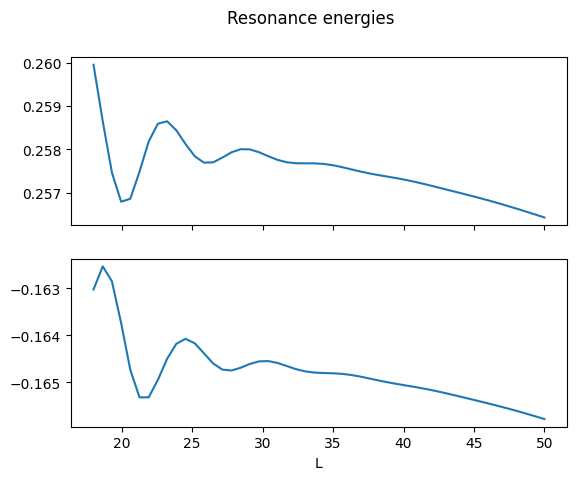

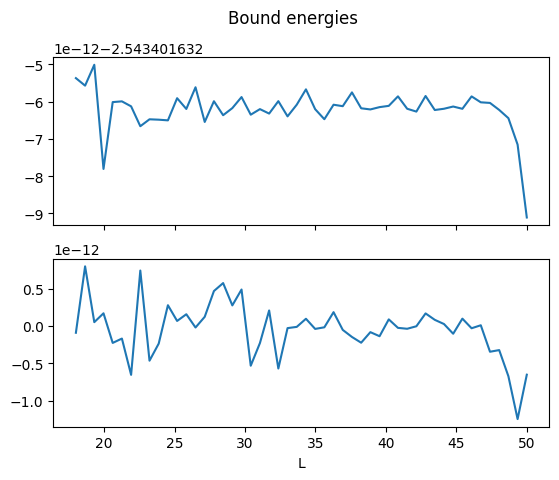

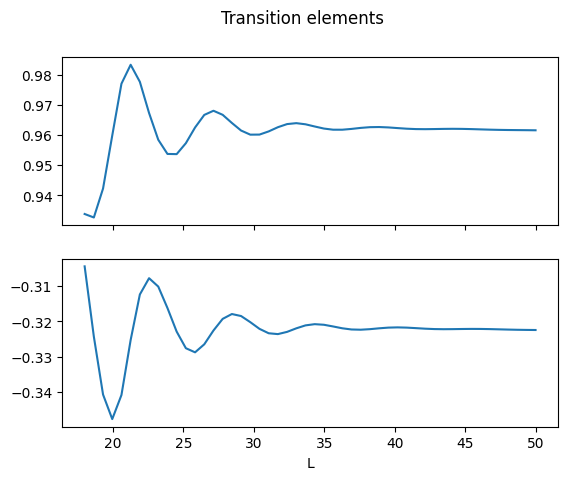

In [7]:
plot_ys = [res_eigvals, bound_eigvals, transition_elements]
titles = ['Resonance energies', 'Bound energies', 'Transition elements']
for i, y in enumerate(plot_ys):
    fig, [ax1, ax2] = plt.subplots(nrows=2, ncols=1, sharex=True)
    ax1.plot(Ls, np.real(y), label='Real')
    ax2.plot(Ls, np.imag(y), label='Imag')
    ax2.set_xlabel("L")
    fig.suptitle(titles[i])
    plt.show()

### Compute resonance energy, bound state energy, transition matrix element, and complex-scaled resonance wavefunction for several $\phi$.

In [8]:
phis = np.linspace(.45, .75, 20)

res_eigvals = []
bound_eigvals = []
transition_elements = []
res_states = []
for phi in phis:
    pres_system.reset_rotation_angle(phi)
    sbound_system.reset_rotation_angle(phi)
    
    res_energy, res_state = pres_system.closest_to_resonance(resonance=real_res)
    res_states.append(res_state)
    bound_energy, bound_state = sbound_system.closest_to_resonance(resonance=real_bound)

    t_elem = DVR.compute_transition_mat_element(L, bound_state[:, 0], res_state[:, 0], rotation_angle=phi, operator="E1")
    
    res_eigvals.append(res_energy[0])
    bound_eigvals.append(bound_energy[0])
    transition_elements.append(t_elem)

res_eigvals = np.array(res_eigvals)
bound_eigvals = np.array(bound_eigvals)
transition_elements = np.array(transition_elements)

In [9]:
# compute the median and std
res_mean, res_std = np.mean(res_eigvals), np.std(np.real(res_eigvals)) + 1j*np.std(np.imag(res_eigvals))
print(f"Resonance energy: ({np.real(res_mean):.5f} +- {np.real(res_std):.5f}) + i({np.imag(res_mean):.5f} +- {np.imag(res_std):.5f})")

bound_mean, bound_std = np.mean(bound_eigvals), np.std(np.real(bound_eigvals)) + 1j*np.std(np.imag(bound_eigvals))
print(f"Bound energy: ({np.real(bound_mean):.5f} +- {np.real(bound_std):.5f}) + i({np.imag(bound_mean):.5f} +- {np.imag(bound_std):.5f})")

telem_mean, telem_std = np.mean(transition_elements), np.std(np.real(transition_elements)) + 1j*np.std(np.imag(transition_elements))
print(f"Transition element: ({np.real(telem_mean):.5f} +- {np.real(telem_std):.5f}) + i({np.imag(telem_mean):.5f} +- {np.imag(telem_std):.5f})")

Resonance energy: (0.25687 +- 0.00050) + i(-0.16608 +- 0.00037)
Bound energy: (-2.54340 +- 0.00000) + i(-0.00000 +- 0.00000)
Transition element: (0.96194 +- 0.00035) + i(-0.32274 +- 0.00026)


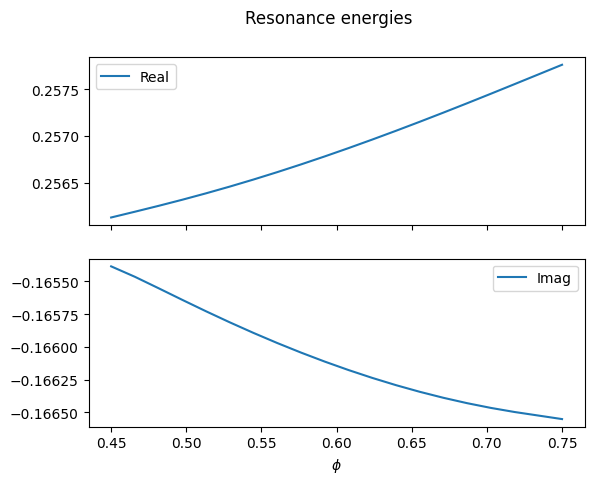

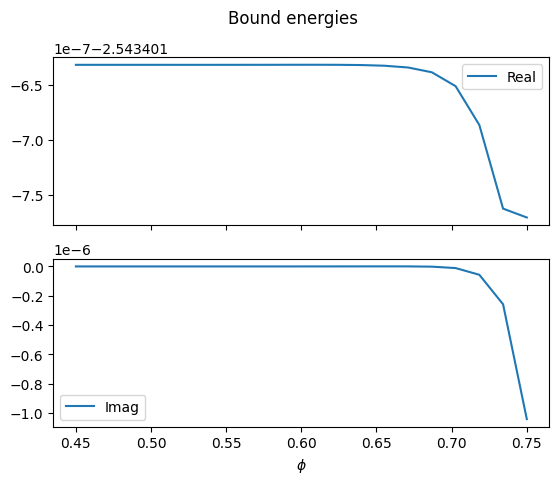

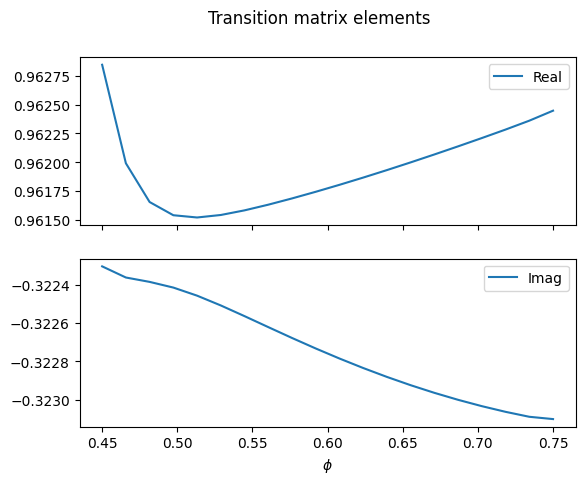

In [10]:
plot_ys = [res_eigvals, bound_eigvals, transition_elements]
titles = ['Resonance energies', 'Bound energies', 'Transition matrix elements']
for i, y in enumerate(plot_ys):
    fig, [ax1, ax2] = plt.subplots(nrows=2, ncols=1, sharex=True)
    ax1.plot(phis, np.real(y), label='Real')
    ax2.plot(phis, np.imag(y), label='Imag')
    ax2.set_xlabel(r"$\phi$")
    fig.suptitle(titles[i])
    ax1.legend()
    ax2.legend()
    plt.show()

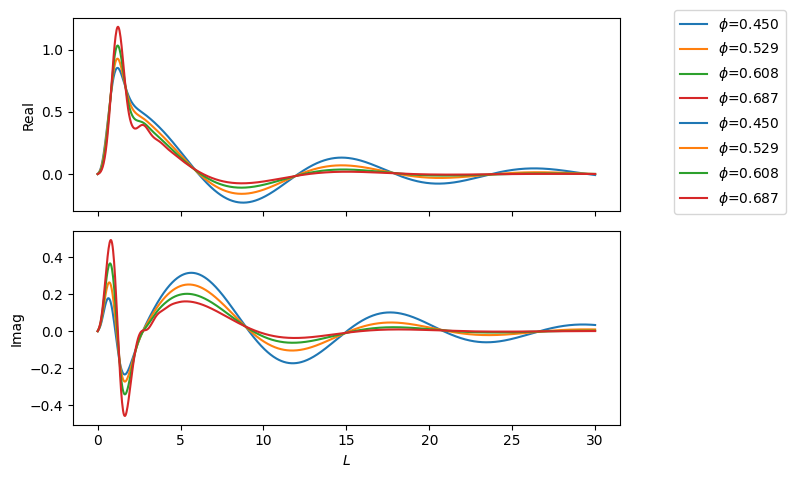

In [11]:
# plot the resonance wavefunctions as a function of phi
x_plot = np.linspace(0, 30, 1000)
fig, ax = plt.subplots(2, 1, sharex=True)
for phi, res in zip(phis[::5],res_states[::5]):
    wavefunc = pres_system.DVR_to_position_space(res, x_plot)
    ax[0].plot(x_plot, np.real(wavefunc), label=fr'$\phi$={phi:.3f}')
    ax[1].plot(x_plot, np.imag(wavefunc), label=fr'$\phi$={phi:.3f}')
    ax[1].set_xlabel(r"$L$")
    ax[0].set_ylabel("Real")
    ax[1].set_ylabel("Imag")
fig.legend(bbox_to_anchor=(1.05,1.), loc='upper left')
plt.tight_layout()
plt.show()

### Compute the bound state energy, resonance energy, and transition matrix element using EC 
From the above plots and stats, the good region of $\phi$ seems to be $\phi\in(.45,.75)$, so we'll use that region for training.

In [12]:
phi_train = np.linspace(0.45, 0.75, 50)

pres_ecsystem = ECSystem(pres_system, real_res)
print("Training...")
pres_ecsystem.train(phi_train)
training_eigvals = pres_ecsystem.training_eigvals
print("Training complete.")
pres_ecsystem.construct_basis()
print("Basis constructed.")

Training...
Training complete.
Basis constructed.


#### Interpolation to $\phi=\pi/6$.
Here, we use EC to interpolate the resonance wavefunction, computing its energy and the transition matrix element $(\psi_\text{bound}|r|\psi_\text{res})$. As seen below, it does this fine.

In [13]:
phi_predict = phi_stable
_, _ = quick_predict(phi_predict, pres_ecsystem)

Bound state energy at phi=0.5235987755982988: -2.5434 + i-0.0000
	 Residual: 0.0000 + i0.0000
Resonance energy prediction at phi=0.5236: 0.2564 + i-0.1658
	 Residual: 0.0018 + i0.0015
Transition matrix element prediction at phi=0.5236: 0.9615 + i-0.3225
	 Residual: 0.0014 + i0.0010


#### Extrapolation to $\phi=0$. 
As seen below, EC struggles with this quite a bit more. My guess: the $p$-wave resonance is very
broad, which gives EC a smaller region to train over and a wider region to "jump across" when extrapolating. 

In [14]:
phi_predict = 0.0
_, _ = quick_predict(phi_predict, pres_ecsystem)

Bound state energy at phi=0.0: -2.5434 + i0.0000
	 Residual: 0.0000 + i0.0000
Resonance energy prediction at phi=0.0000: 0.2203 + i-0.0487
	 Residual: 0.0379 + i0.1156
Transition matrix element prediction at phi=0.0000: 0.0721 + i-0.3430
	 Residual: 0.8908 + i0.0214


#### Test: plot $E(\phi)$ for $\phi\in[0.0, 0.75]$.
This will hopefully tell us how EC is behaving once we leave the good sector.

In [15]:
# TEST: look at rotated prediction as theta goes to zero
good_phis = np.linspace(0.45, 0.75, 5)
bad_phis = np.linspace(0.0, 0.5, 15)
phis = np.concatenate([bad_phis, good_phis])
predict_energies = []

for phi in phis:
    predict_energies.append(pres_ecsystem.predict_DVR_state_at(phi)[0])

b_end = len(bad_phis)

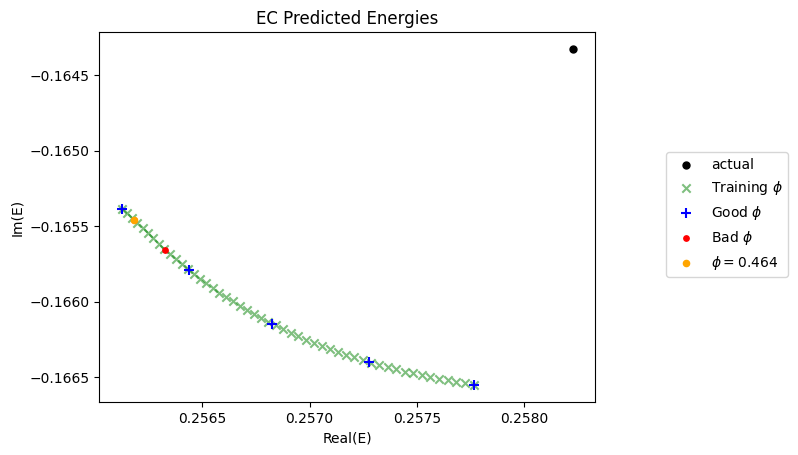

In [16]:
b_end, cutoff = len(bad_phis), 13
fig, ax = plt.subplots()
ax.scatter(np.real(real_res), np.imag(real_res), marker='o', color='black', label='actual', s=25)
ax.scatter(np.real(training_eigvals), np.imag(training_eigvals), color='green', marker='x', alpha=.5,label=r'Training $\phi$')
ax.scatter(np.real(predict_energies[b_end:]), np.imag(predict_energies[b_end:]), color='blue', alpha=1., s=55,marker='+', label=r'Good $\phi$')
ax.scatter(np.real(predict_energies[cutoff:b_end]), np.imag(predict_energies[cutoff:b_end]), color='red', s=15,label=r'Bad $\phi$')
ax.scatter(np.real(predict_energies[cutoff]), np.imag(predict_energies[cutoff]), marker='o', color='orange', s=20, label=rf'$\phi={phis[cutoff]:.3}$')
ax.set_xlabel("Real(E)")
ax.set_ylabel("Im(E)")
ax.set_title("EC Predicted Energies")
fig.legend(loc='center left', bbox_to_anchor=(1.0,.5))
plt.show()

### Compute Transition Elements with EC + Stats

#### Error in EC as number of training points increase

In [17]:
phi_predict = 0.0
n_ecsystems = 128

phi_training_range, num_phi_points_list = [0.45, 0.75], [3, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 75]
ecensemble = ECEnsemble(n_ecsystems, pres_system, real_res)

# train EC ensembles for multiple training points
all_energy_stats, all_telems_stats = [], []
all_energy_resid_stats, all_telems_resid_stats = [], []
for num_phi_points in num_phi_points_list:
    print(f"Training EC on {num_phi_points} training points.")
    ecensemble.train(phi_training_range, num_phi_points)
    ecensemble.construct_bases()
    energies, dvr_states = ecensemble.predict_DVR_states_at(phi_predict)
    telems = np.array([
        DVR.compute_transition_mat_element(
            L, bound_state[:, 0], dvr_state, rotation_angle=phi_predict, operator="E1"
        ) for dvr_state in dvr_states.T
    ])
    
    energy_stats = ECEnsemble.compute_stats(energies)
    energy_resid_stats = ECEnsemble.compute_resid_stats(real_res, energies)

    # phase align telems
    telems *= np.sign(np.real(telems))
    telems_stats = ECEnsemble.compute_stats(telems)
    telems_resid_stats = ECEnsemble.compute_resid_stats(real_telem, telems)

    all_energy_stats.append(energy_stats)
    all_energy_resid_stats.append(energy_resid_stats)

    all_telems_stats.append(telems_stats)
    all_telems_resid_stats.append(telems_resid_stats)
    ecensemble.clear_all()

Training EC on 3 training points.
Training EC on 5 training points.
Training EC on 10 training points.
Training EC on 15 training points.
Training EC on 20 training points.
Training EC on 25 training points.
Training EC on 30 training points.
Training EC on 35 training points.
Training EC on 40 training points.
Training EC on 45 training points.
Training EC on 50 training points.
Training EC on 75 training points.


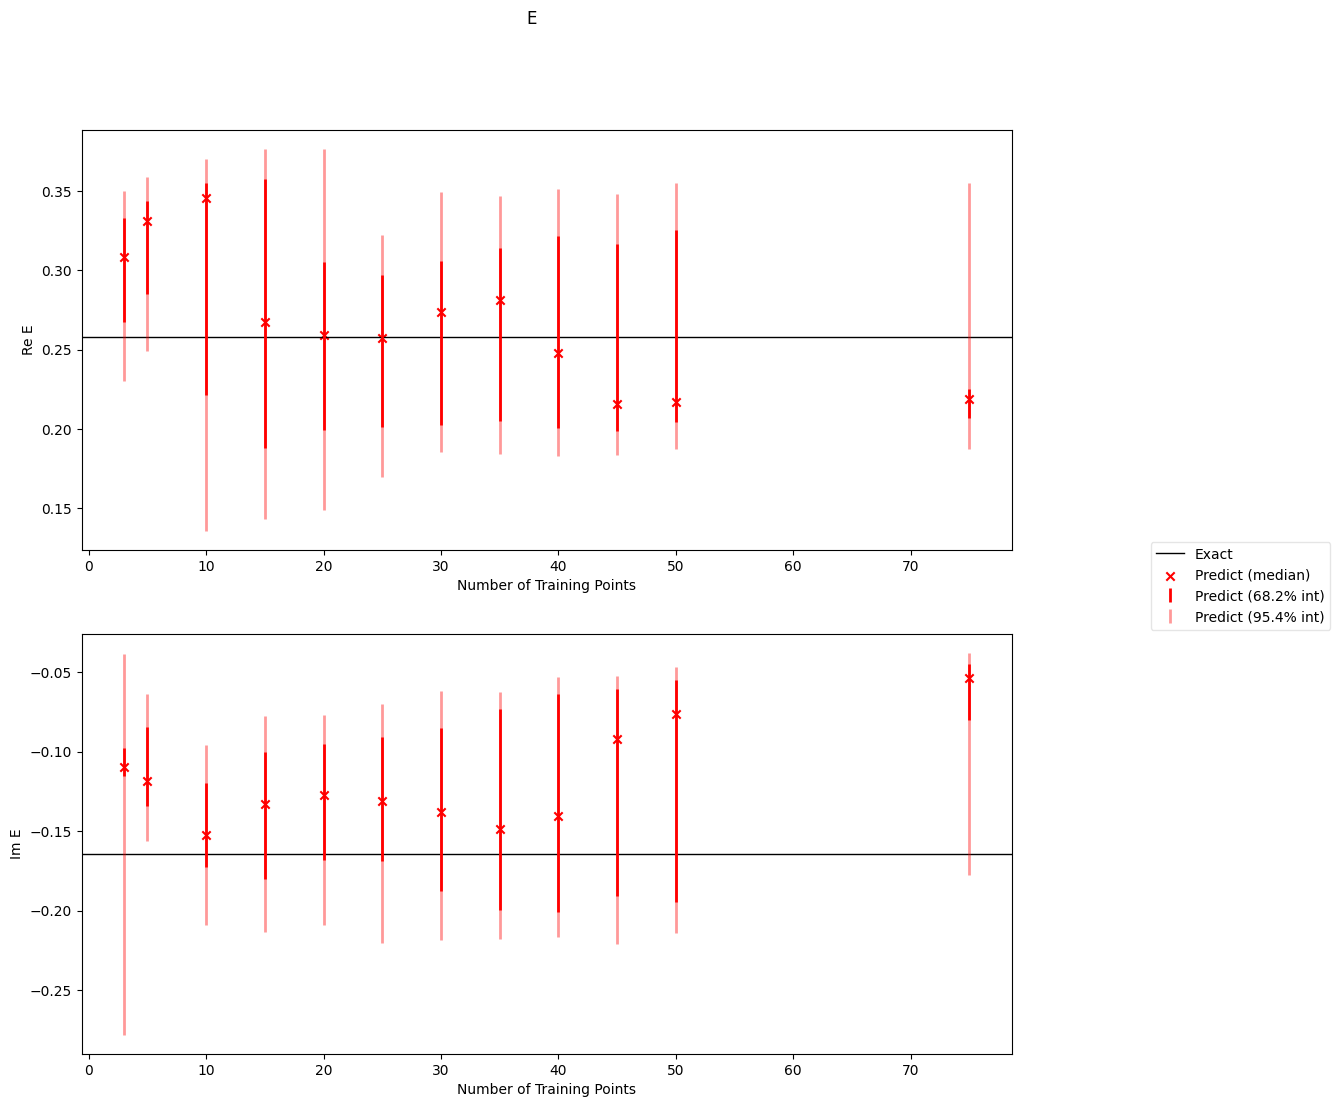

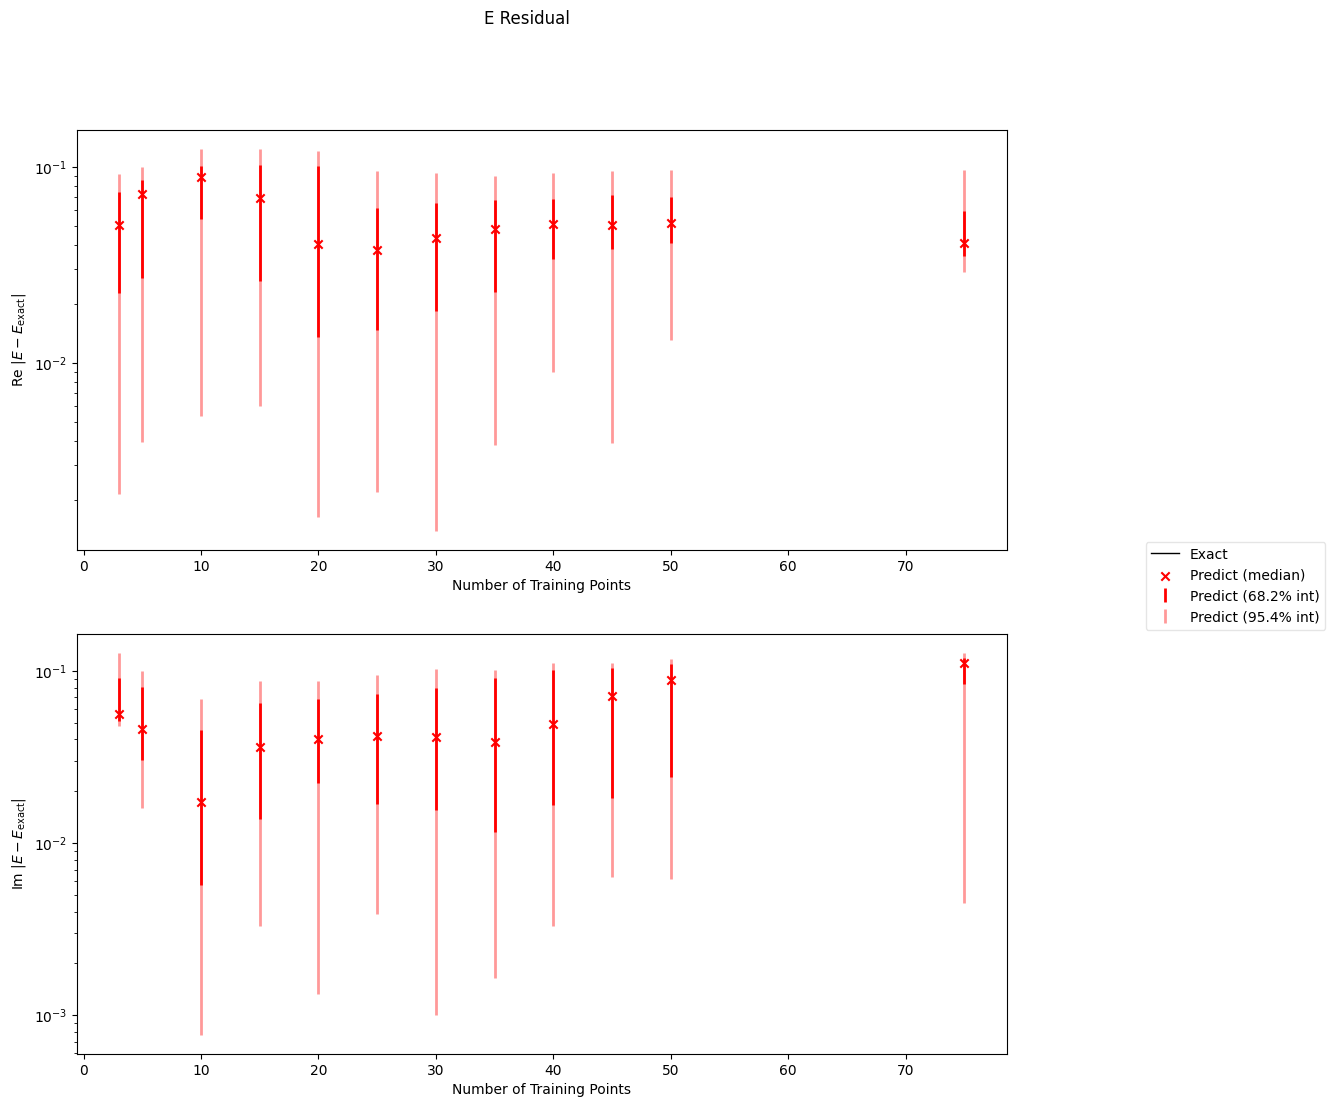

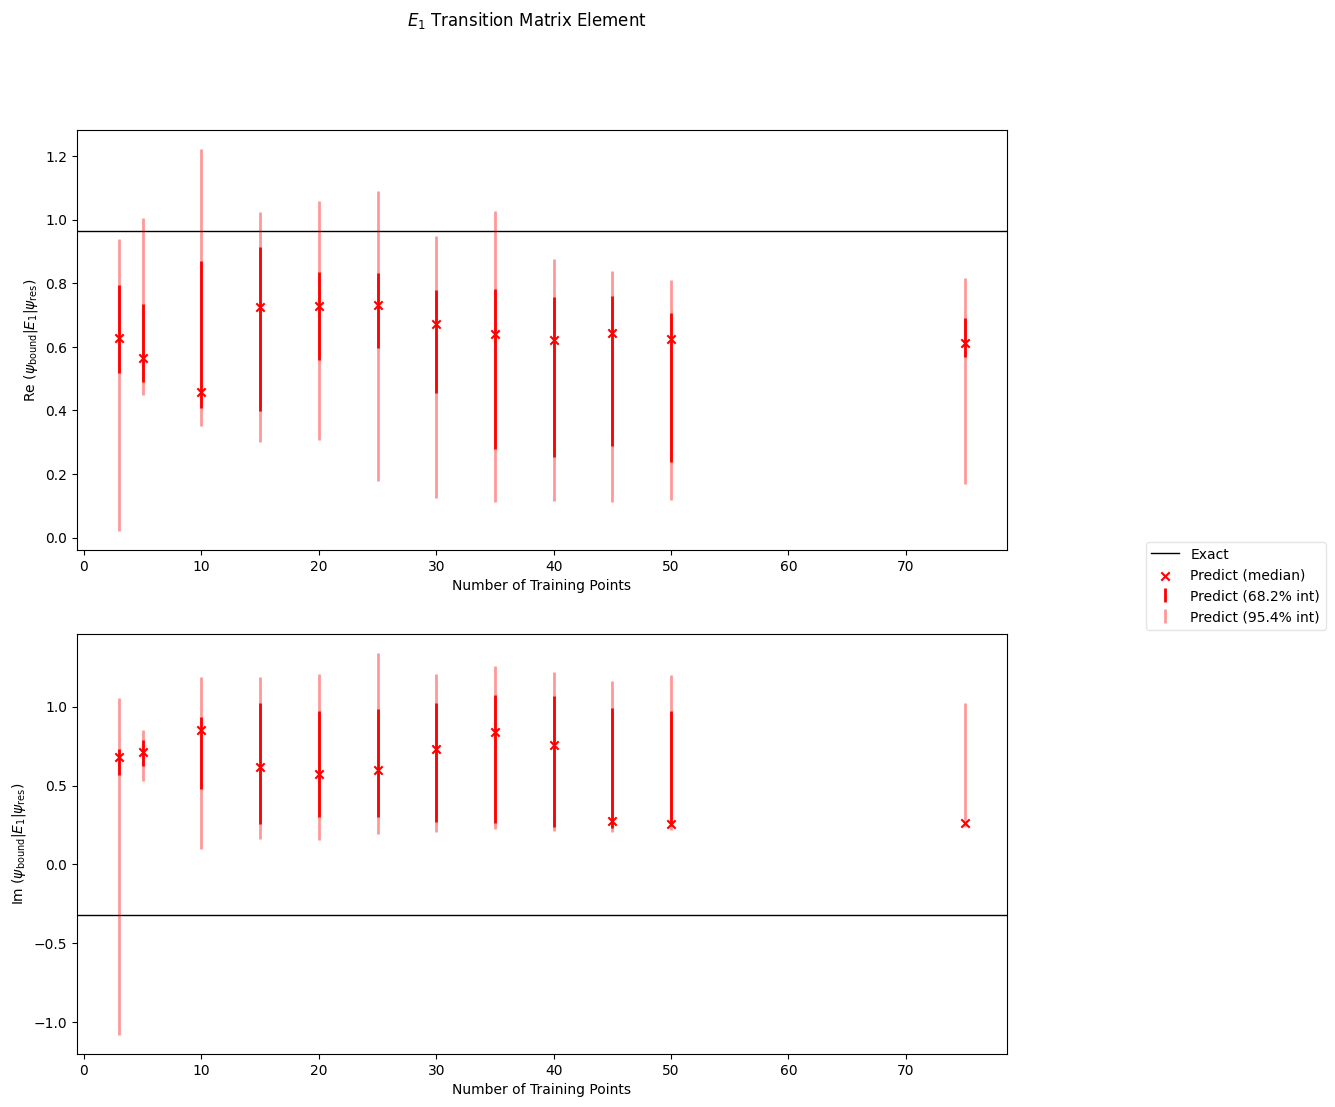

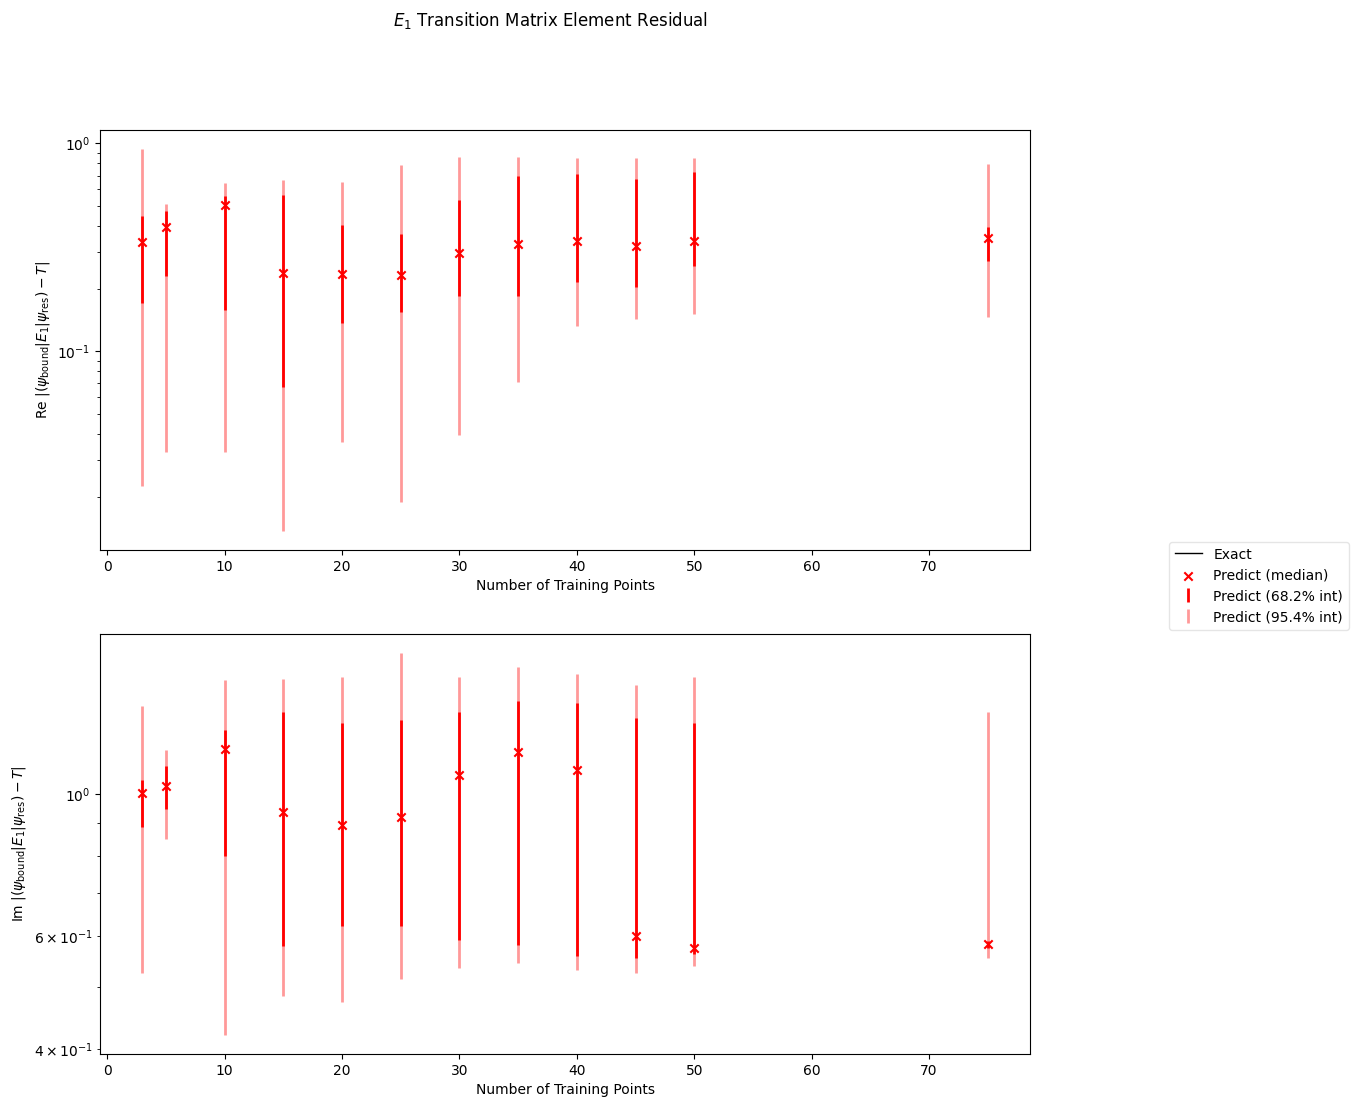

In [18]:
def plot(fig, ax, exact, xs, data, **kwargs):
    axreal, aximag = ax
    # get stats from data
    med, err68, err95 = decompose_stats(data)

    # get plot kwargs
    title = kwargs.get("title", "")
    ylabel = kwargs.get("ylabel", "")
    xlabel = kwargs.get("xlabel", "")
    scale = kwargs.get("scale", "linear")
    cutoff = kwargs.get("cutoff", 0)
    color = kwargs.get("color", "red")

    # plot real and imaginary components
    axreal.axhline(y=np.real(exact), color='black', linewidth=1.0, linestyle='-', label='Exact')
    aximag.axhline(y=np.imag(exact), color='black', linewidth=1.0, linestyle='-', label='Exact')
    plot_stats(fig, (axreal, aximag), xs, med, err68, err95, cutoff=cutoff, color=color)

    # set labels, title, and legend
    axreal.set_ylabel(f"Re {ylabel}")
    aximag.set_ylabel(f"Im {ylabel}")
    aximag.set_xlabel(xlabel)
    axreal.set_xlabel(xlabel)
    axreal.set_yscale(scale)
    aximag.set_yscale(scale)
    fig.suptitle(f"{title}")

    handles, labels = axreal.get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5), framealpha=0.5)
    axreal.legend().remove()
    aximag.legend().remove()
    return fig, (axreal, aximag)

# Plot energy and energy residuals
figsize=(12, 12)
fig, (axreal, aximag) = plt.subplots(2, 1, figsize=figsize)
plot_kwargs = {"ylabel": "E", "xlabel": r"Number of Training Points", "title": "E"}
_ = plot(fig, (axreal, aximag), real_res, num_phi_points_list, all_energy_stats, **plot_kwargs)
if save_plots: fig.savefig(plots_folder / "system2_ec_backrotated_E_wrt_trainingpoints.png")
plt.show()

fig, (axreal, aximag) = plt.subplots(2, 1, figsize=figsize)
plot_kwargs = {"ylabel": r"|$E-E_\text{exact}$|", "xlabel": r"Number of Training Points", "title": "E Residual", "scale": "log"}
_ = plot(fig, (axreal, aximag), 0.0+1j*0.0, num_phi_points_list, all_energy_resid_stats, **plot_kwargs)
if save_plots: fig.savefig(plots_folder / "system2_ec_backrotated_Eresid_wrt_trainingpoints.png")
plt.show()

fig, (axreal, aximag) = plt.subplots(2, 1, figsize=figsize)
plot_kwargs = {"ylabel": r"$(\psi_\text{bound}|E_1|\psi_\text{res})$", "xlabel": 
               r"Number of Training Points", "title": r"$E_1$ Transition Matrix Element"}
_ = plot(fig, (axreal, aximag), real_telem, num_phi_points_list, all_telems_stats, **plot_kwargs)
if save_plots: fig.savefig(plots_folder / "system2_ec_backrotated_telem_wrt_trainingpoints.png")
plt.show()

fig, (axreal, aximag) = plt.subplots(2, 1, figsize=figsize)
plot_kwargs = {"ylabel": r"$|(\psi_\text{bound}|E_1|\psi_\text{res})-T|$", 
               "xlabel": r"Number of Training Points", "title": r"$E_1$ Transition Matrix Element Residual", "scale": "log"}
_ = plot(fig, (axreal, aximag), 0.0, num_phi_points_list, all_telems_resid_stats, **plot_kwargs)
if save_plots: fig.savefig(plots_folder / "system2_ec_backrotated_telem_resid_wrt_trainingpoints.png")
plt.show()

#### Error in EC as training region grows

In [19]:
# train EC ensembles for multiple training points
mid_phi, widths = 0.534, np.arange(0.05, 0.65, 0.05)
phi_training_ranges, num_phi_points = [[mid_phi-width/2, mid_phi+width/2] for width in widths], 10
all_energy_stats, all_energy_resid_stats = [], []
all_telems_stats, all_telems_resid_stats = [], []
for phi_training_range in phi_training_ranges:
    print(f"Training EC on {phi_training_range} training range.")
    ecensemble.train(phi_training_range, num_phi_points)
    ecensemble.construct_bases()
    energies, dvr_states = ecensemble.predict_DVR_states_at(phi_predict)
    telems = np.array([
        DVR.compute_transition_mat_element(
            L, bound_state[:, 0], dvr_state, rotation_angle=phi_predict, operator="E1"
        ) for dvr_state in dvr_states.T
    ])
    
    energy_stats = ECEnsemble.compute_stats(energies)
    energy_resid_stats = ECEnsemble.compute_resid_stats(real_res, energies)

    telems_stats = ECEnsemble.compute_stats(telems)
    telems_resid_stats = ECEnsemble.compute_resid_stats(real_telem, telems)

    all_energy_stats.append(energy_stats)
    all_energy_resid_stats.append(energy_resid_stats)

    all_telems_stats.append(telems_stats)
    all_telems_resid_stats.append(telems_resid_stats)
    ecensemble.clear_all()

Training EC on [np.float64(0.509), np.float64(0.559)] training range.
Training EC on [np.float64(0.48400000000000004), np.float64(0.5840000000000001)] training range.
Training EC on [np.float64(0.459), np.float64(0.609)] training range.
Training EC on [np.float64(0.43400000000000005), np.float64(0.634)] training range.
Training EC on [np.float64(0.40900000000000003), np.float64(0.659)] training range.
Training EC on [np.float64(0.384), np.float64(0.684)] training range.
Training EC on [np.float64(0.359), np.float64(0.7090000000000001)] training range.
Training EC on [np.float64(0.334), np.float64(0.734)] training range.
Training EC on [np.float64(0.30900000000000005), np.float64(0.759)] training range.
Training EC on [np.float64(0.28400000000000003), np.float64(0.784)] training range.
Training EC on [np.float64(0.259), np.float64(0.809)] training range.
Training EC on [np.float64(0.23399999999999999), np.float64(0.8340000000000001)] training range.


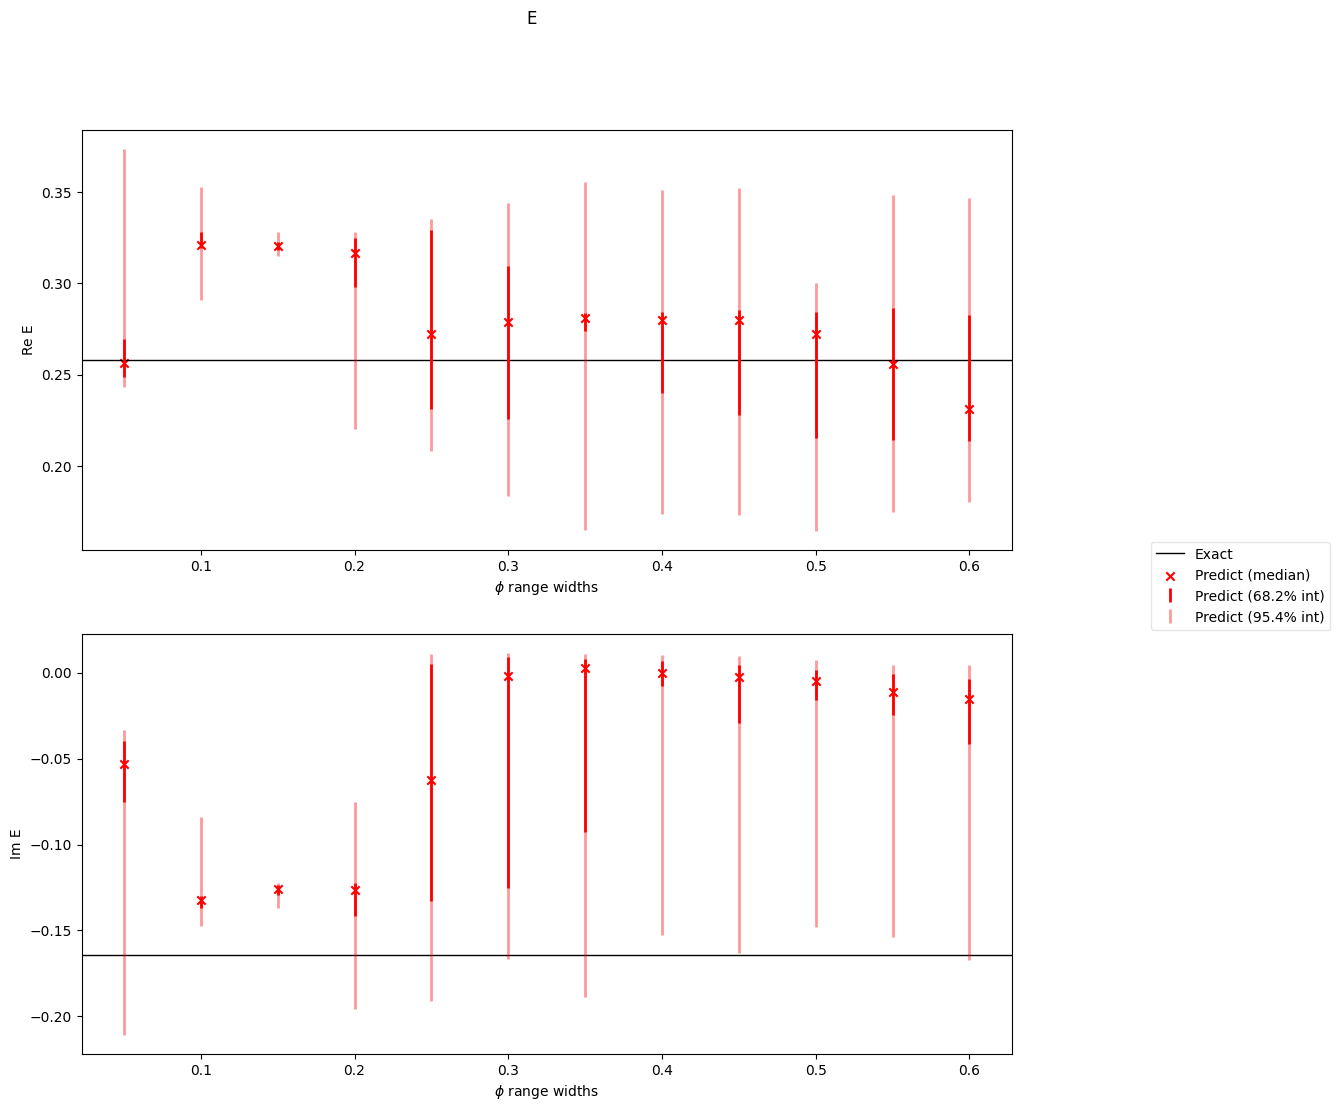

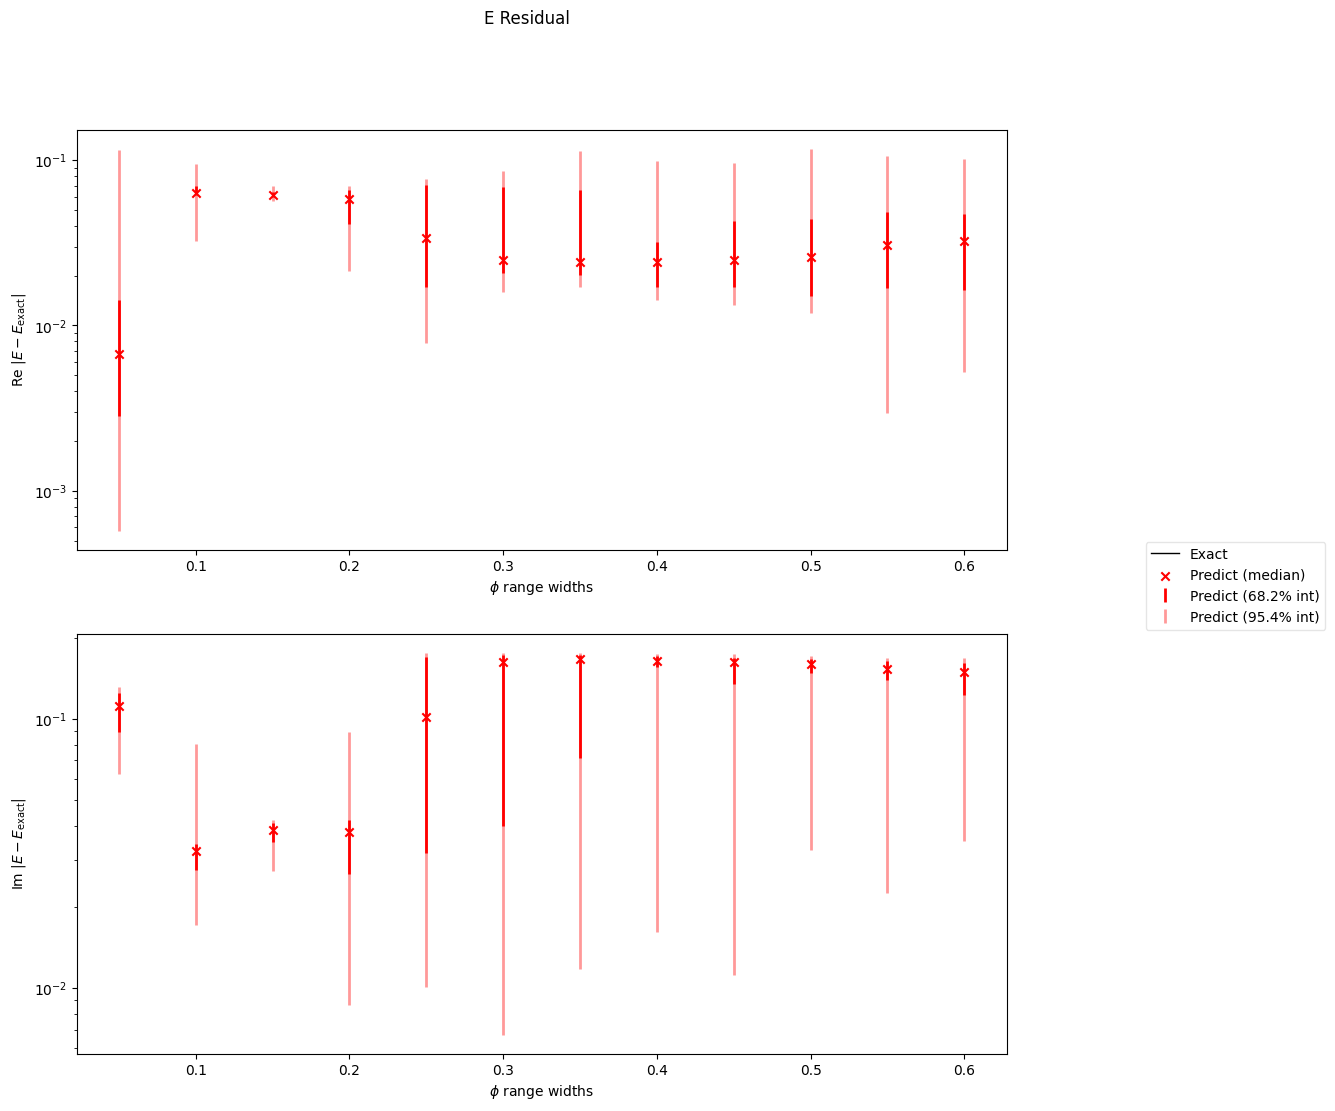

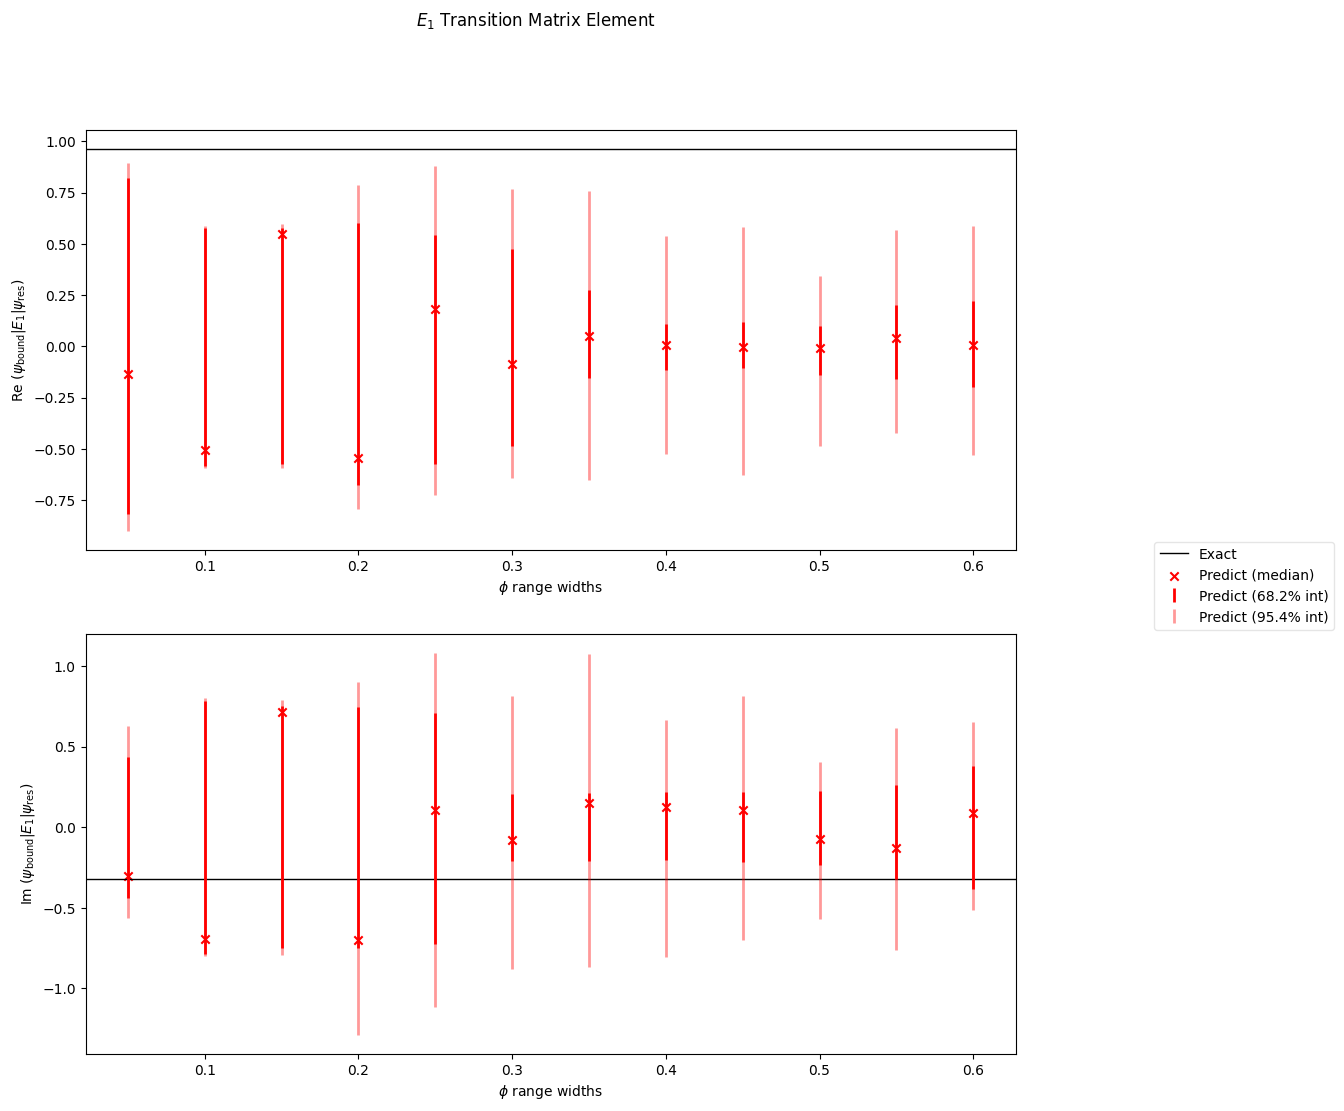

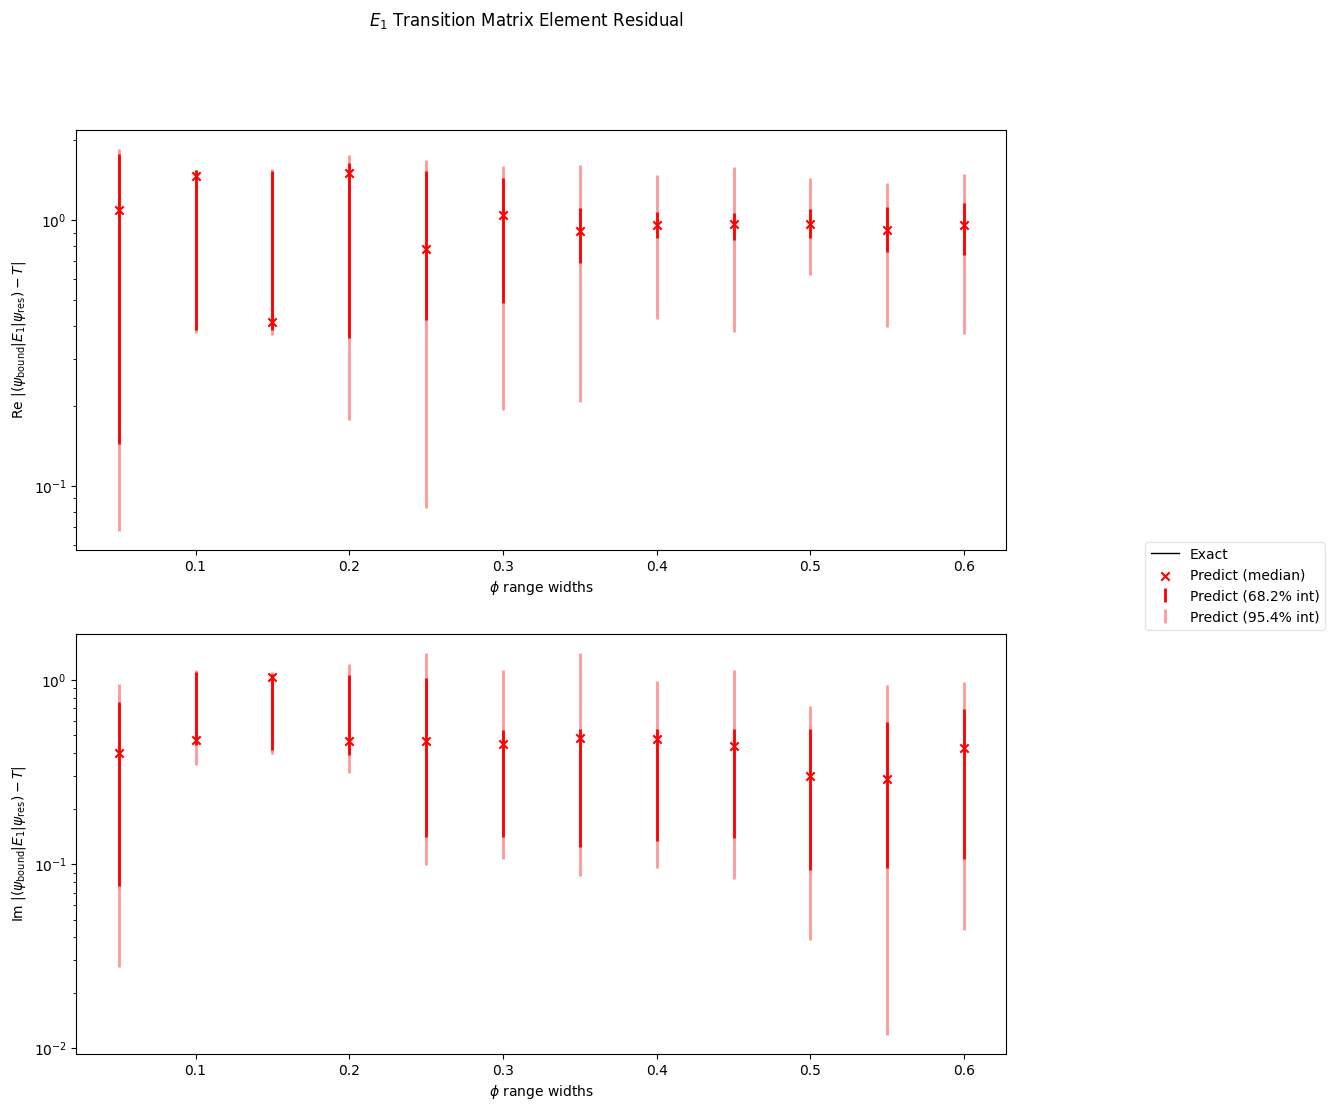

In [20]:
# Plot energy and energy residuals
cutoff = 0
fig, (axreal, aximag) = plt.subplots(2, 1, figsize=figsize)
plot_kwargs = {"ylabel": "E", "xlabel": r"$\phi$ range widths", "title": "E", "cutoff": cutoff}
_ = plot(fig, (axreal, aximag), real_res, widths, all_energy_stats, **plot_kwargs)
if save_plots: fig.savefig(plots_folder / "system2_ec_backrotated_E_wrt_trainingregion.png")
plt.show()

fig, (axreal, aximag) = plt.subplots(2, 1, figsize=figsize)
plot_kwargs = {"ylabel": r"|$E-E_\text{exact}$|", "xlabel": r"$\phi$ range widths",
               "title": "E Residual", "scale": "log", "cutoff":cutoff}
_ = plot(fig, (axreal, aximag), 0.0+1j*0.0, widths, all_energy_resid_stats, **plot_kwargs)
if save_plots: fig.savefig(plots_folder / "system2_ec_backrotated_E_wrt_trainingregion.png")
plt.show()

fig, (axreal, aximag) = plt.subplots(2, 1, figsize=figsize)
plot_kwargs = {"ylabel": r"$(\psi_\text{bound}|E_1|\psi_\text{res})$", "xlabel": 
               r"$\phi$ range widths", "title": r"$E_1$ Transition Matrix Element", "cutoff": cutoff}
_ = plot(fig, (axreal, aximag), real_telem, widths, all_telems_stats, **plot_kwargs)
if save_plots: fig.savefig(plots_folder / "system2_ec_backrotated_E_wrt_trainingregion.png")
plt.show()

fig, (axreal, aximag) = plt.subplots(2, 1, figsize=figsize)
plot_kwargs = {"ylabel": r"$|(\psi_\text{bound}|E_1|\psi_\text{res})-T|$", 
               "xlabel": r"$\phi$ range widths", "title": r"$E_1$ Transition Matrix Element Residual",
               "scale": "log", "cutoff": cutoff}
_ = plot(fig, (axreal, aximag), 0.0, widths, all_telems_resid_stats, **plot_kwargs)
if save_plots: fig.savefig(plots_folder / "system2_ec_backrotated_E_wrt_trainingregion.png")
plt.show()

#### Error in EC as number of training points grows for a few different training window ranges

In [21]:
widths = np.linspace(0.05, 0.65, 5)
phi_training_ranges = [[mid_phi-width/2, mid_phi+width/2] for width in widths]
num_phi_points_list = [3, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 75]
ecensemble = ECEnsemble(n_ecsystems, pres_system, real_res)

# train EC ensembles for multiple training points
all_energy_stats, all_telems_stats = [], []
all_energy_resid_stats, all_telems_resid_stats = [], []
for phi_training_range in phi_training_ranges:
    print(f"Training EC on {phi_training_range}.")
    t_energy_stats, t_telems_stats = [], []
    t_energy_resid_stats, t_telems_resid_stats = [], []
    for num_phi_points in num_phi_points_list:
        print(f"Training EC on {num_phi_points} training points.")
        ecensemble.train(phi_training_range, num_phi_points)
        ecensemble.construct_bases()
        energies, dvr_states = ecensemble.predict_DVR_states_at(phi_predict)
        telems = np.array([
            DVR.compute_transition_mat_element(
                L, bound_state[:, 0], dvr_state, rotation_angle=phi_predict, operator="E1"
            ) for dvr_state in dvr_states.T
        ])
        
        energy_stats = ECEnsemble.compute_stats(energies)
        energy_resid_stats = ECEnsemble.compute_resid_stats(real_res, energies)
    
        telems_stats = ECEnsemble.compute_stats(telems)
        telems_resid_stats = ECEnsemble.compute_resid_stats(real_telem, telems)
    
        t_energy_stats.append(energy_stats)
        t_energy_resid_stats.append(energy_resid_stats)
    
        t_telems_stats.append(telems_stats)
        t_telems_resid_stats.append(telems_resid_stats)
    all_energy_stats.append(t_energy_stats)
    all_energy_resid_stats.append(t_energy_resid_stats)
    
    all_telems_stats.append(t_telems_stats)
    all_telems_resid_stats.append(t_telems_resid_stats)
    ecensemble.clear_all()

Training EC on [np.float64(0.509), np.float64(0.559)].
Training EC on 3 training points.
Training EC on 5 training points.
Training EC on 10 training points.
Training EC on 15 training points.
Training EC on 20 training points.
Training EC on 25 training points.
Training EC on 30 training points.
Training EC on 35 training points.
Training EC on 40 training points.
Training EC on 45 training points.
Training EC on 50 training points.
Training EC on 75 training points.
Training EC on [np.float64(0.43400000000000005), np.float64(0.634)].
Training EC on 3 training points.
Training EC on 5 training points.
Training EC on 10 training points.
Training EC on 15 training points.
Training EC on 20 training points.
Training EC on 25 training points.
Training EC on 30 training points.
Training EC on 35 training points.
Training EC on 40 training points.
Training EC on 45 training points.
Training EC on 50 training points.
Training EC on 75 training points.
Training EC on [np.float64(0.35900000000

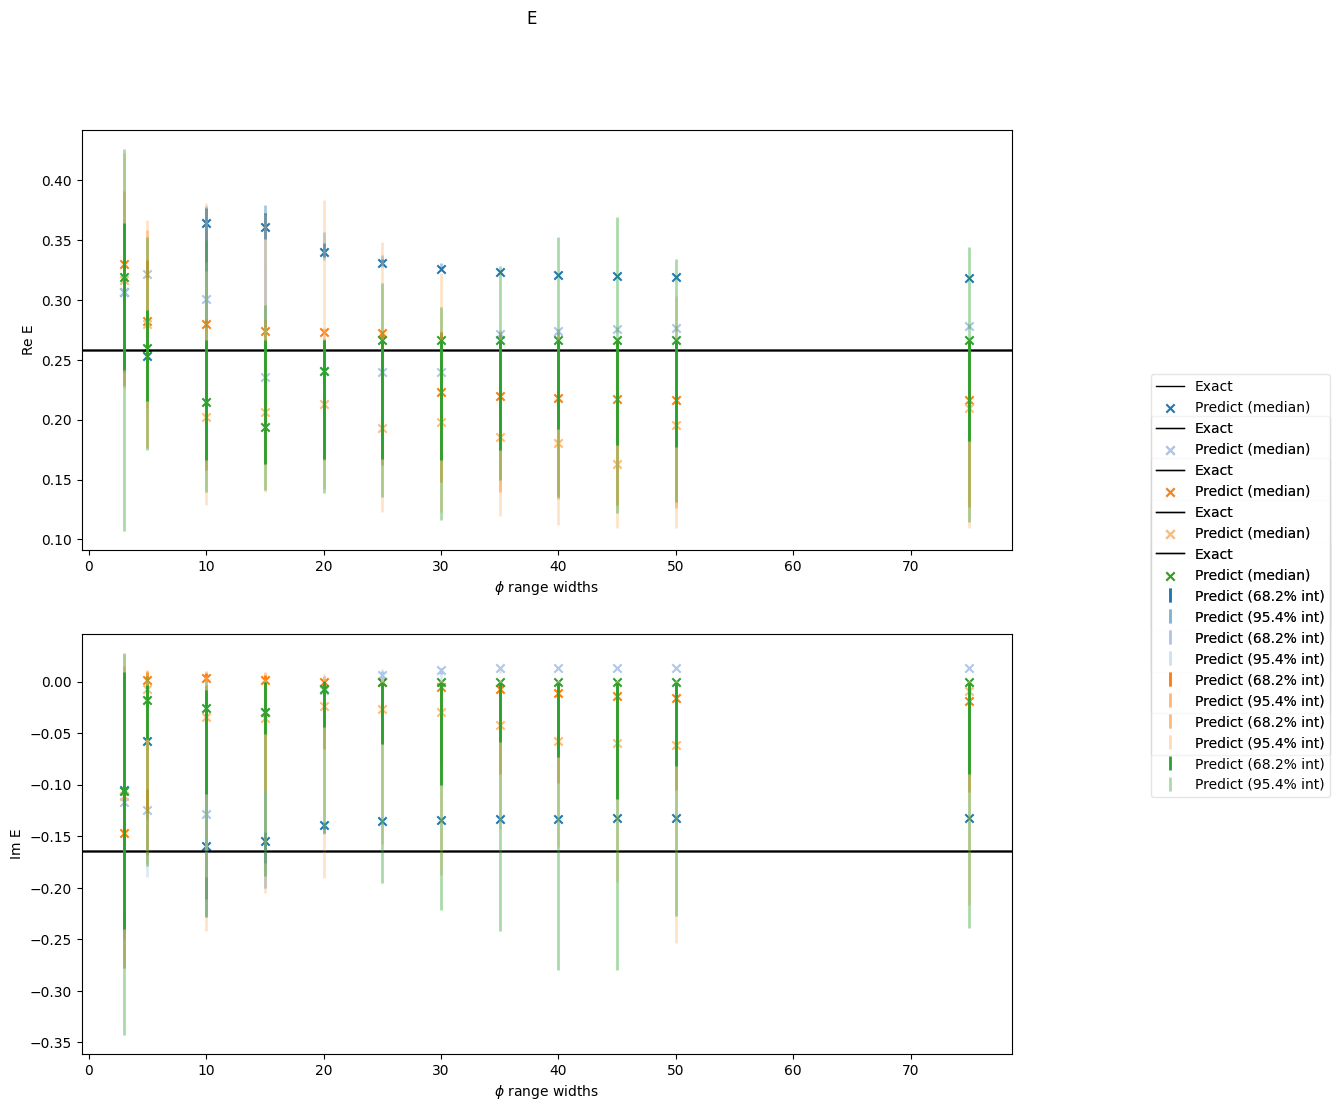

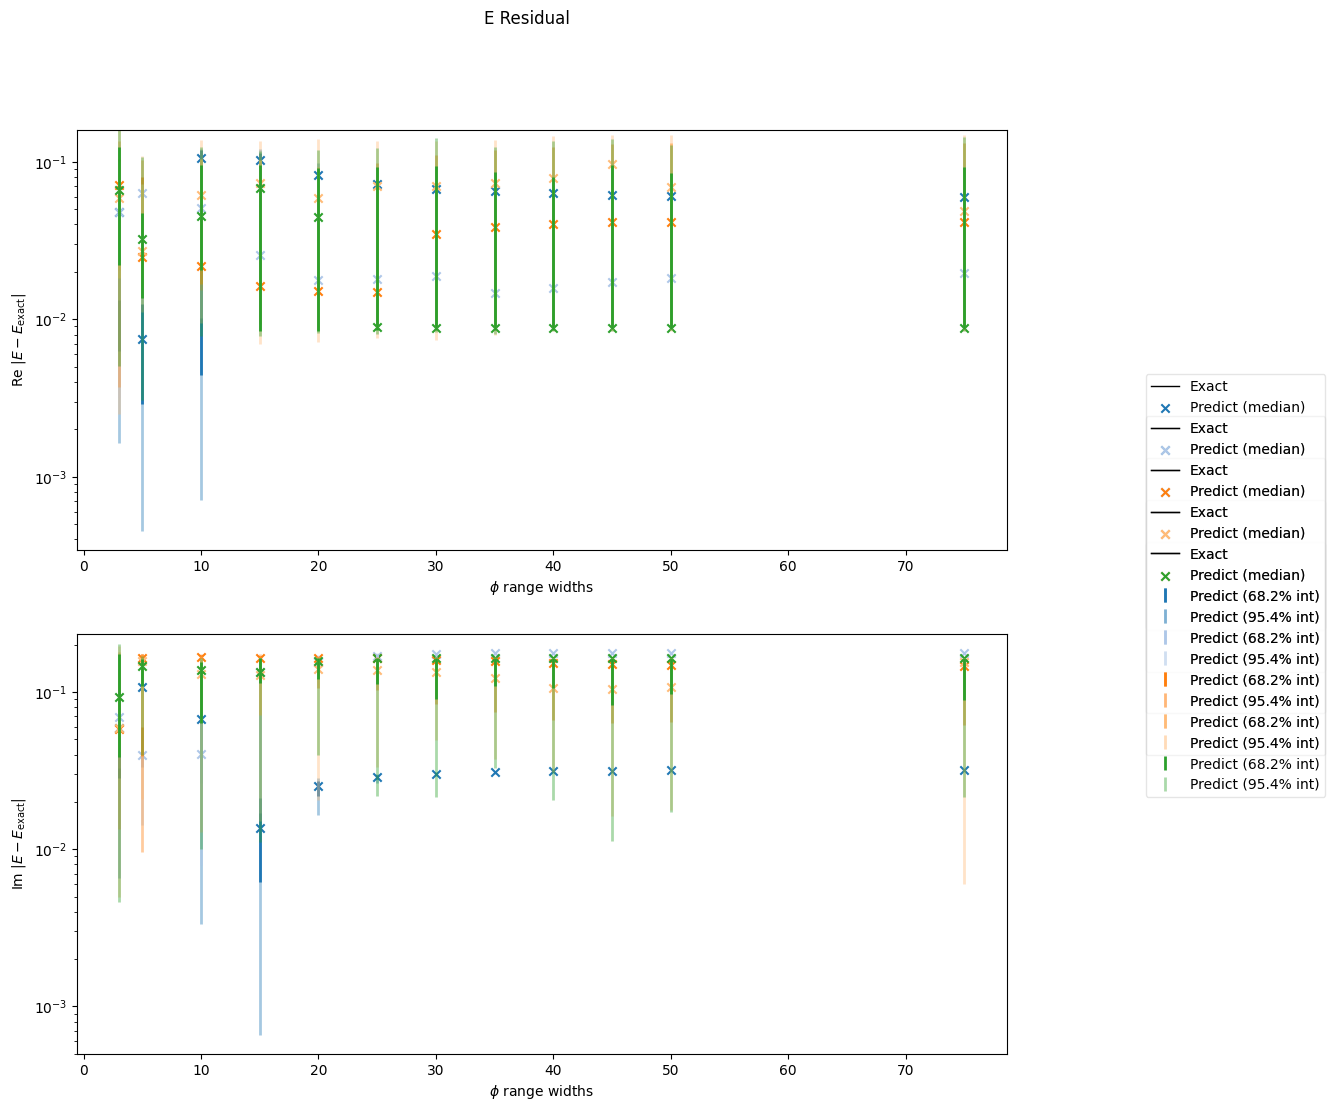

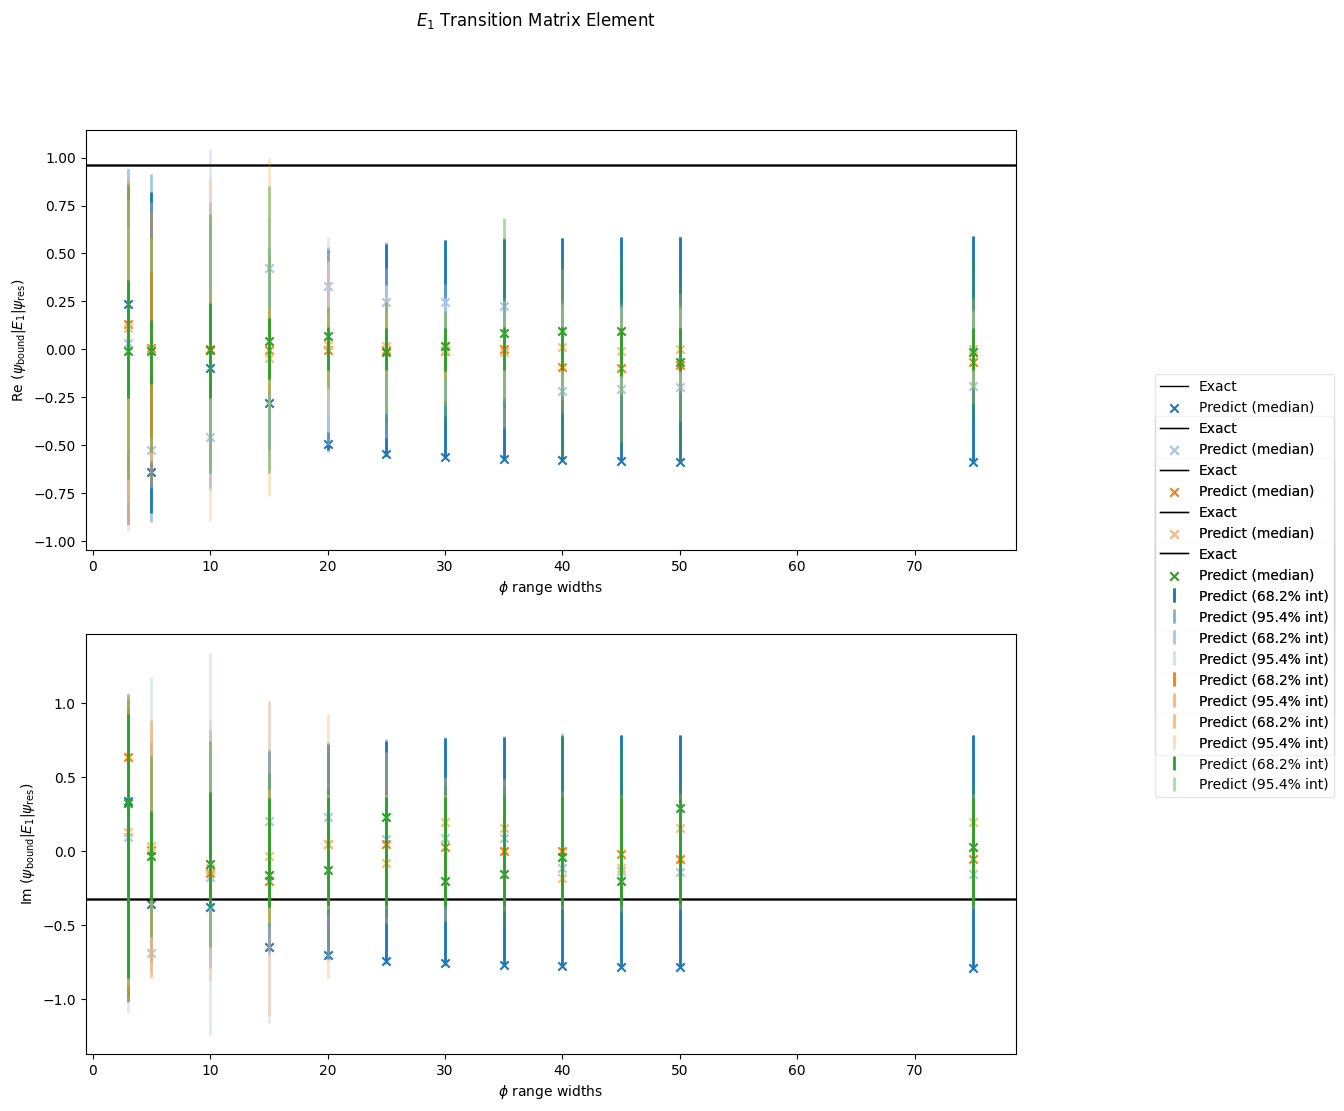

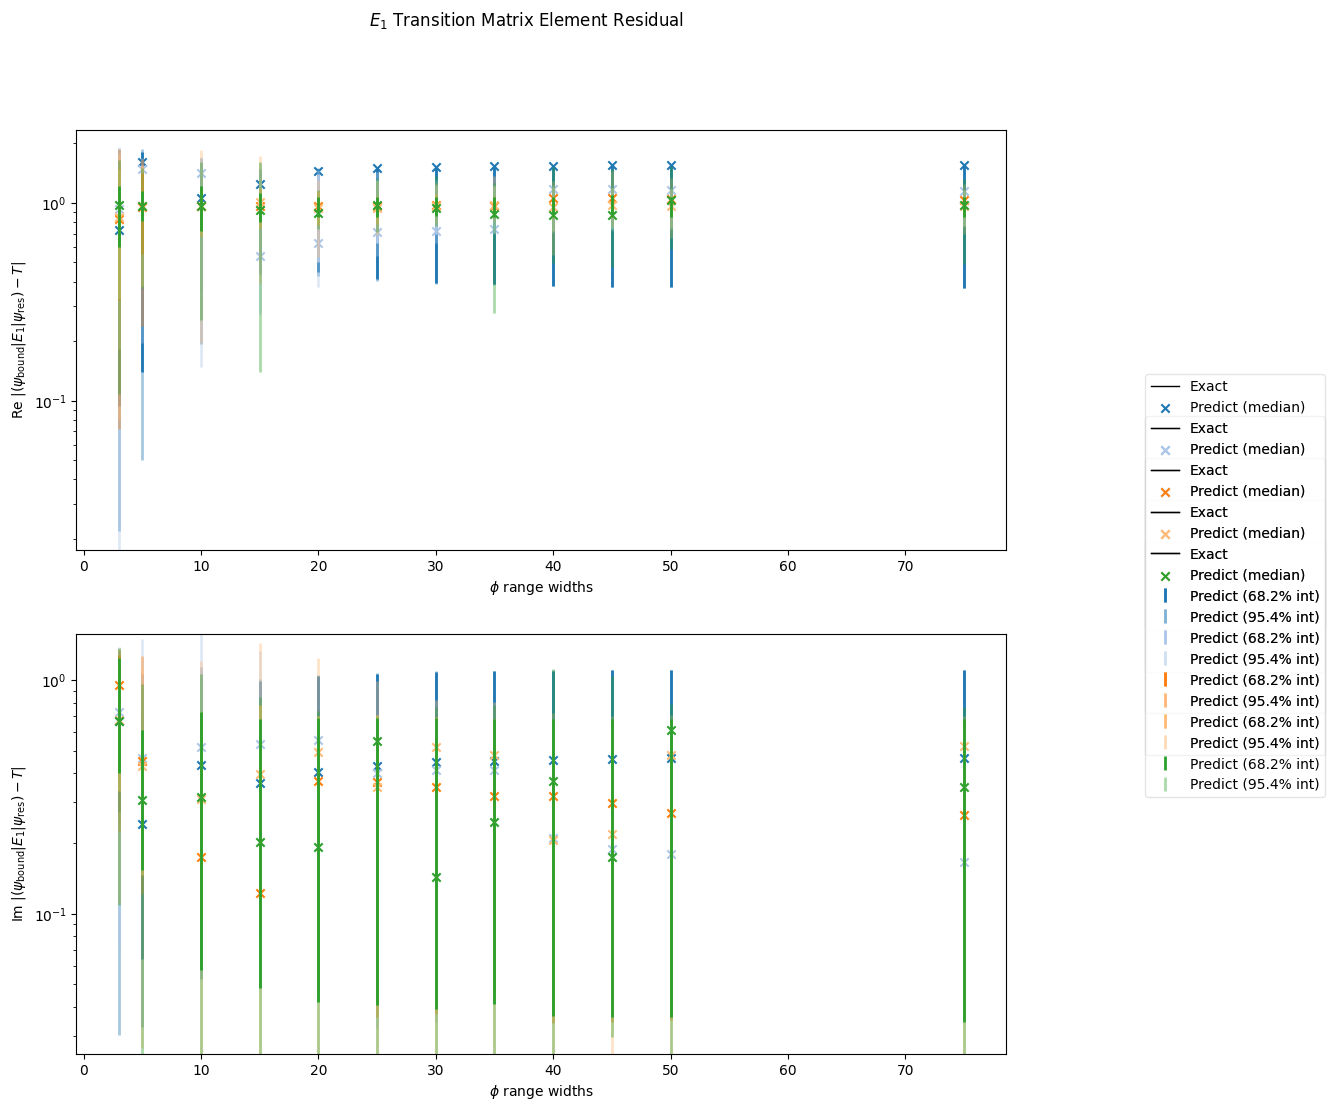

In [22]:
# Plot energy and energy residuals
cutoff = 0
colors = plt.colormaps["tab20"].colors

figsize=(12, 12)
fig_e, (axreal_e, aximag_e) = plt.subplots(2, 1, figsize=figsize)
fig_er, (axreal_er, aximag_er) = plt.subplots(2, 1, figsize=figsize)
fig_t, (axreal_t, aximag_t) = plt.subplots(2, 1, figsize=figsize)
fig_tr, (axreal_tr, aximag_tr) = plt.subplots(2, 1, figsize=figsize)
for i in range(len(phi_training_ranges)):
    plot_kwargs = {"ylabel": "E", "xlabel": r"$\phi$ range widths", "title": "E", "color": colors[i], "cutoff": cutoff}
    _ = plot(fig_e, (axreal_e, aximag_e), real_res, num_phi_points_list, all_energy_stats[i], **plot_kwargs)
    
    plot_kwargs = {"ylabel": r"|$E-E_\text{exact}$|", "xlabel": r"$\phi$ range widths",
                   "title": "E Residual", "scale": "log", "color": colors[i], "cutoff": cutoff}
    _ = plot(fig_er, (axreal_er, aximag_er), 0.0+1j*0.0,  num_phi_points_list, all_energy_resid_stats[i], **plot_kwargs)
    
    plot_kwargs = {"ylabel": r"$(\psi_\text{bound}|E_1|\psi_\text{res})$", "xlabel": 
                   r"$\phi$ range widths", "title": r"$E_1$ Transition Matrix Element", "color": colors[i], "cutoff": cutoff}
    _ = plot(fig_t, (axreal_t, aximag_t), real_telem,  num_phi_points_list, all_telems_stats[i], **plot_kwargs)

    plot_kwargs = {"ylabel": r"$|(\psi_\text{bound}|E_1|\psi_\text{res})-T|$", 
                   "xlabel": r"$\phi$ range widths", "title": r"$E_1$ Transition Matrix Element Residual",
                   "scale": "log", "color": colors[i], "cutoff": cutoff}
    _ = plot(fig_tr, (axreal_tr, aximag_tr), 0.0,  num_phi_points_list, all_telems_resid_stats[i], **plot_kwargs)

if save_plots:
    fig_e.savefig(plots_folder / "system2_ec_backrotated_E_wrt_trainingpoints_&_trainingregion.png")
    fig_er.savefig(plots_folder / "system2_ec_backrotated_E_resid_wrt_trainingpoints_&_trainingregion.png")
    fig_t.savefig(plots_folder / "system2_ec_backrotated_telem_wrt_trainingpoints_&_trainingregion.png")
    fig_tr.savefig(plots_folder / "system2_ec_backrotated_telem_wrt_trainingregion.png")